# Multiple Linear Regression on Wireless Weather Data

In [1]:
import pandas as pd

In [2]:
# Define the path to your directory containing Excel files
# You can use a wildcard '*' to match all Excel files (.xlsx or .xls): 
# 
wireless_weather_data_path = "C:/Users/ukhan/Documents/DataSet/OpenMesh/wireless_weather_data_638K.csv"

In [10]:
ww_df = pd.read_csv(wireless_weather_data_path)

In [11]:
ww_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,rsl,nr_site_0_lat,nr_site_0_lon,DATE,LATITUDE,...,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS,GD1_HEIGHT_MTS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,-60.0,40.77898,-73.96925,2023-10-29 00:51:00,40.77898,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
1,2023-10-29 00:51:00,2,-59.0,60480,222.1,-62.0,40.77898,-73.96925,2023-10-29 00:51:00,40.77898,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
2,2023-10-29 00:51:00,3,-61.0,62640,623.0,-60.0,40.77898,-73.96925,2023-10-29 00:51:00,40.77898,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
3,2023-10-29 00:51:00,4,-56.0,58320,451.8,-57.0,40.77898,-73.96925,2023-10-29 00:51:00,40.77898,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
4,2023-10-29 00:51:00,5,-58.0,60480,222.1,-57.0,40.77898,-73.96925,2023-10-29 00:51:00,40.77898,...,222,144,10176,1829.0,0,0,1,0,0,10186.0


In [12]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length', 'rsl',
       'nr_site_0_lat', 'nr_site_0_lon', 'DATE', 'LATITUDE', 'LONGITUDE',
       'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V',
       'CIG_AGL', 'VIS_DISTANCE_MTS', 'TMP_C', 'DEW_TMP_C', 'SLP_HECTOPASCALS',
       'GD1_HEIGHT_MTS', 'GD1__1', 'GD1__2', 'GD1__3', 'GD1__4', 'GD1__5',
       'MA1_ALTIMETER_HECTOPASCAL'],
      dtype='object')

In [13]:
ww_df.drop(columns=['DATE', 'nr_site_0_lat', 'nr_site_0_lon'], inplace=True)

In [14]:
ww_df.sublink_id.value_counts(ascending=True)

13    2720
64    2766
46    3541
58    3652
96    3754
      ... 
17    6641
18    6660
44    6665
55    6687
25    6783
Name: sublink_id, Length: 103, dtype: int64

In [15]:
ww_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581376 entries, 0 to 581375
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Datetime                   581376 non-null  object 
 1   sublink_id                 581376 non-null  int64  
 2   rsl_value                  581376 non-null  float64
 3   frequency                  581376 non-null  int64  
 4   length                     581376 non-null  float64
 5   rsl                        581376 non-null  float64
 6   LATITUDE                   581376 non-null  float64
 7   LONGITUDE                  581376 non-null  float64
 8   ELEVATION                  581376 non-null  float64
 9   WND_SPEED_MPS              581376 non-null  int64  
 10  WND_TYPE_CODE_N            581376 non-null  int64  
 11  WND_TYPE_CODE_V            581376 non-null  int64  
 12  CIG_AGL                    581376 non-null  int64  
 13  VIS_DISTANCE_MTS           58

In [16]:
ww_df.Datetime = pd.to_datetime(ww_df.Datetime)

## Analysis

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
ww_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,rsl,LATITUDE,LONGITUDE,ELEVATION,WND_SPEED_MPS,...,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS,GD1_HEIGHT_MTS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,-60.0,40.77898,-73.96925,42.7,36,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
1,2023-10-29 00:51:00,2,-59.0,60480,222.1,-62.0,40.77898,-73.96925,42.7,36,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
2,2023-10-29 00:51:00,3,-61.0,62640,623.0,-60.0,40.77898,-73.96925,42.7,36,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
3,2023-10-29 00:51:00,4,-56.0,58320,451.8,-57.0,40.77898,-73.96925,42.7,36,...,222,144,10176,1829.0,0,0,1,0,0,10186.0
4,2023-10-29 00:51:00,5,-58.0,60480,222.1,-57.0,40.77898,-73.96925,42.7,36,...,222,144,10176,1829.0,0,0,1,0,0,10186.0


In [19]:
ww_df['rsl_change'] = ww_df['rsl']-ww_df['rsl_value']

In [20]:
ww_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,rsl,LATITUDE,LONGITUDE,ELEVATION,WND_SPEED_MPS,...,DEW_TMP_C,SLP_HECTOPASCALS,GD1_HEIGHT_MTS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL,rsl_change
0,2023-10-29 00:51:00,1,-65.0,62640,623.0,-60.0,40.77898,-73.96925,42.7,36,...,144,10176,1829.0,0,0,1,0,0,10186.0,5.0
1,2023-10-29 00:51:00,2,-59.0,60480,222.1,-62.0,40.77898,-73.96925,42.7,36,...,144,10176,1829.0,0,0,1,0,0,10186.0,-3.0
2,2023-10-29 00:51:00,3,-61.0,62640,623.0,-60.0,40.77898,-73.96925,42.7,36,...,144,10176,1829.0,0,0,1,0,0,10186.0,1.0
3,2023-10-29 00:51:00,4,-56.0,58320,451.8,-57.0,40.77898,-73.96925,42.7,36,...,144,10176,1829.0,0,0,1,0,0,10186.0,-1.0
4,2023-10-29 00:51:00,5,-58.0,60480,222.1,-57.0,40.77898,-73.96925,42.7,36,...,144,10176,1829.0,0,0,1,0,0,10186.0,1.0


In [23]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length', 'rsl',
       'LATITUDE', 'LONGITUDE', 'ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'CIG_AGL', 'VIS_DISTANCE_MTS',
       'TMP_C', 'DEW_TMP_C', 'SLP_HECTOPASCALS', 'GD1_HEIGHT_MTS', 'GD1__1',
       'GD1__2', 'GD1__3', 'GD1__4', 'GD1__5', 'MA1_ALTIMETER_HECTOPASCAL',
       'rsl_change'],
      dtype='object')

In [24]:
ww_df.describe()

,sublink_id,rsl_value,frequency,length,rsl,LATITUDE,LONGITUDE,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,...,DEW_TMP_C,SLP_HECTOPASCALS,GD1_HEIGHT_MTS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL,rsl_change
count,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,...,581376.000000,581376.000000,383370.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000
mean,52.062442,-59.914766,29612.713562,1702.633728,-59.880814,40.712912,-74.003044,8.232848,145.616353,0.592462,...,43.615043,28122.407989,1009.018883,0.106346,0.096292,0.159649,0.296128,0.001003,10157.452778,0.033952
std,29.288550,7.583067,28037.212205,1346.394382,7.250629,0.027801,0.014220,14.503384,1067.554332,0.491377,...,79.622929,35931.230828,923.049971,0.308280,0.294992,0.366280,0.456549,0.031651,534.940550,5.879023
min,1.000000,-96.000000,5270.000000,24.500000,-83.000000,40.701214,-74.009028,2.130000,0.000000,0.000000,...,-183.000000,9823.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9827.000000,-38.000000
25%,26.000000,-65.000000,5560.000000,631.400000,-64.000000,40.701214,-74.009028,2.130000,15.000000,0.000000,...,-17.000000,10118.000000,274.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10091.000000,-1.000000
50%,52.000000,-59.000000,5810.000000,1447.500000,-59.000000,40.701214,-74.009028,2.130000,26.000000,1.000000,...,44.000000,10184.000000,640.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10156.000000,0.000000
75%,77.000000,-56.000000,64800.000000,2392.700000,-56.000000,40.701214,-74.009028,2.130000,41.000000,1.000000,...,100.000000,10309.000000,1524.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10213.000000,2.000000
max,103.000000,-19.000000,69120.000000,6936.500000,-34.000000,40.778980,-73.969250,42.700000,9999.000000,1.000000,...,244.000000,99999.000000,3658.000000,1.000000,1.000000,1.000000,1.000000,1.000000,99999.000000,38.000000


In [25]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length', 'rsl',
       'LATITUDE', 'LONGITUDE', 'ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'CIG_AGL', 'VIS_DISTANCE_MTS',
       'TMP_C', 'DEW_TMP_C', 'SLP_HECTOPASCALS', 'GD1_HEIGHT_MTS', 'GD1__1',
       'GD1__2', 'GD1__3', 'GD1__4', 'GD1__5', 'MA1_ALTIMETER_HECTOPASCAL',
       'rsl_change'],
      dtype='object')

## Temperature
* Temperature is defined with scaling factor of 10

In [36]:
ww_df.TMP_C.describe()

count    581376.000000
mean         10.430350
std           7.481657
min          -7.200000
25%           5.000000
50%           9.000000
75%          15.000000
max          34.400000
Name: TMP_C, dtype: float64

In [27]:
(ww_df.TMP_C==9999).value_counts()

False    581376
Name: TMP_C, dtype: int64

In [35]:
ww_df.TMP_C = ww_df.TMP_C.apply(lambda x: x/10)

In [28]:
ww_df = ww_df[ww_df.TMP_C!=9999]

In [34]:
ww_df[ww_df.TMP_C > 50].shape

(432405, 25)

<Axes: >

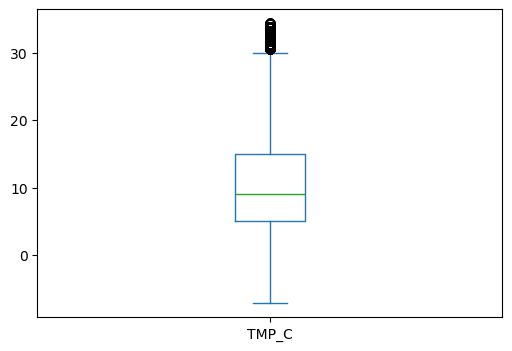

In [37]:
ww_df['TMP_C'].plot.box(figsize=(6,4))

In [39]:
#Convert temperature to fahrenheit
ww_df['TMP_F'] = ww_df.TMP_C.apply(lambda x: (x * 9/5) + 32) 

In [40]:
ww_df = ww_df.drop(columns=['TMP_C'])

In [42]:
ww_df['TMP_F'].describe()

count    581376.000000
mean         50.774630
std          13.466982
min          19.040000
25%          41.000000
50%          48.200000
75%          59.000000
max          93.920000
Name: TMP_F, dtype: float64

In [41]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length', 'rsl',
       'LATITUDE', 'LONGITUDE', 'ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'CIG_AGL', 'VIS_DISTANCE_MTS',
       'DEW_TMP_C', 'SLP_HECTOPASCALS', 'GD1_HEIGHT_MTS', 'GD1__1', 'GD1__2',
       'GD1__3', 'GD1__4', 'GD1__5', 'MA1_ALTIMETER_HECTOPASCAL', 'rsl_change',
       'TMP_F'],
      dtype='object')

## Visibility Distance

In [43]:
ww_df.VIS_DISTANCE_MTS.describe()

count    581376.000000
mean      14060.018568
std        4126.794432
min         402.000000
25%       16093.000000
50%       16093.000000
75%       16093.000000
max       16093.000000
Name: VIS_DISTANCE_MTS, dtype: float64

<Axes: >

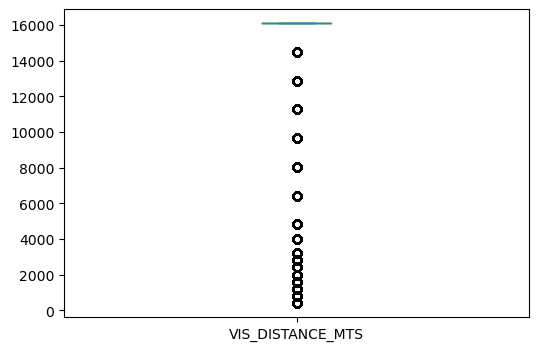

In [45]:
ww_df.VIS_DISTANCE_MTS.plot.box(figsize=(6,4))

<Axes: >

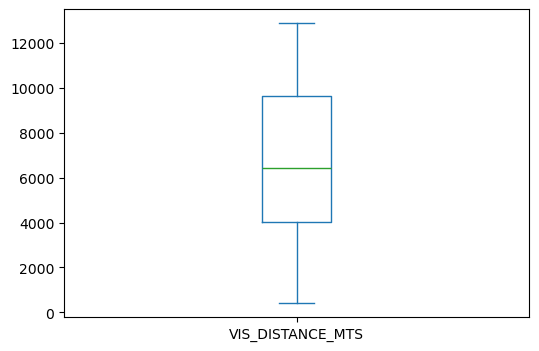

In [47]:
ww_df[ww_df.VIS_DISTANCE_MTS<14000].VIS_DISTANCE_MTS.plot.box(figsize=(6,4))

In [48]:
ww_df[ww_df.VIS_DISTANCE_MTS==16093].shape[0]/ww_df.shape[0]*100

75.33265907089388

In [21]:
#75% dataset consist of single VIS distance value, hence this value can give class imbalance problem

(638586, 16)

In [49]:
ww_df.VIS_DISTANCE_MTS.describe()

count    581376.000000
mean      14060.018568
std        4126.794432
min         402.000000
25%       16093.000000
50%       16093.000000
75%       16093.000000
max       16093.000000
Name: VIS_DISTANCE_MTS, dtype: float64

In [50]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length', 'rsl',
       'LATITUDE', 'LONGITUDE', 'ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'CIG_AGL', 'VIS_DISTANCE_MTS',
       'DEW_TMP_C', 'SLP_HECTOPASCALS', 'GD1_HEIGHT_MTS', 'GD1__1', 'GD1__2',
       'GD1__3', 'GD1__4', 'GD1__5', 'MA1_ALTIMETER_HECTOPASCAL', 'rsl_change',
       'TMP_F'],
      dtype='object')

In [52]:
ww_df[['ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'CIG_AGL', 'VIS_DISTANCE_MTS',
       'DEW_TMP_C', 'SLP_HECTOPASCALS', 'GD1_HEIGHT_MTS', 'GD1__1', 'GD1__2',
       'GD1__3', 'GD1__4', 'GD1__5', 'MA1_ALTIMETER_HECTOPASCAL', 'rsl_change',
       'TMP_F']].describe()

,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,WND_TYPE_CODE_V,CIG_AGL,VIS_DISTANCE_MTS,DEW_TMP_C,SLP_HECTOPASCALS,GD1_HEIGHT_MTS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL,rsl_change,TMP_F
count,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,383370.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000,581376.000000
mean,8.232848,145.616353,0.592462,0.292680,10084.017729,14060.018568,43.615043,28122.407989,1009.018883,0.106346,0.096292,0.159649,0.296128,0.001003,10157.452778,0.033952,50.774630
std,14.503384,1067.554332,0.491377,0.454993,10406.925921,4126.794432,79.622929,35931.230828,923.049971,0.308280,0.294992,0.366280,0.456549,0.031651,534.940550,5.879023,13.466982
min,2.130000,0.000000,0.000000,0.000000,30.000000,402.000000,-183.000000,9823.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9827.000000,-38.000000,19.040000
25%,2.130000,15.000000,0.000000,0.000000,549.000000,16093.000000,-17.000000,10118.000000,274.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10091.000000,-1.000000,41.000000
50%,2.130000,26.000000,1.000000,0.000000,2438.000000,16093.000000,44.000000,10184.000000,640.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10156.000000,0.000000,48.200000
75%,2.130000,41.000000,1.000000,1.000000,22000.000000,16093.000000,100.000000,10309.000000,1524.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10213.000000,2.000000,59.000000
max,42.700000,9999.000000,1.000000,1.000000,22000.000000,16093.000000,244.000000,99999.000000,3658.000000,1.000000,1.000000,1.000000,1.000000,1.000000,99999.000000,38.000000,93.920000


In [69]:
(ww_df['WND_SPEED_MPS']==9999).value_counts()

False    460342
Name: WND_SPEED_MPS, dtype: int64

In [55]:
ww_df = ww_df[ww_df['WND_SPEED_MPS']!=9999]

<Axes: >

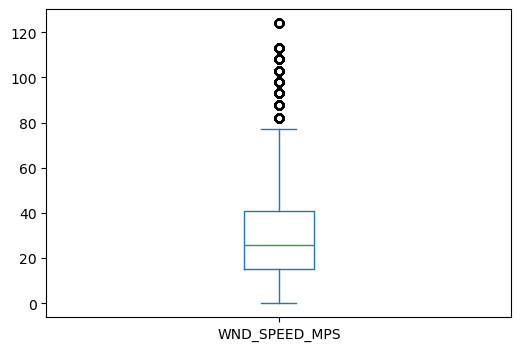

In [70]:
ww_df.WND_SPEED_MPS.plot.box(figsize=(6,4))

In [76]:
ww_df[ww_df.WND_SPEED_MPS>80].shape

(6141, 25)

In [77]:
ww_df = ww_df[ww_df.WND_SPEED_MPS<80]

<Axes: >

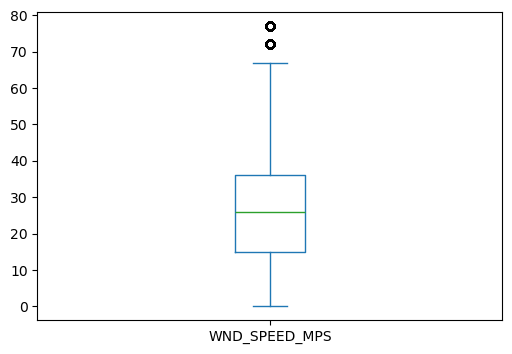

In [78]:
ww_df.WND_SPEED_MPS.plot.box(figsize=(6,4))

In [54]:
(ww_df['DEW_TMP_C']==9999).value_counts()

False    581376
Name: DEW_TMP_C, dtype: int64

In [58]:
ww_df['DEW_TMP_F'] = ww_df['DEW_TMP_C'].apply(lambda x: ((x/10)*(9/5))+32)

C:\Users\ukhan\AppData\Local\Temp\ipykernel_17712\2591355800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ww_df['DEW_TMP_F'] = ww_df['DEW_TMP_C'].apply(lambda x: ((x/10)*(9/5))+32)


In [59]:
ww_df['DEW_TMP_F'].describe()

count    574633.000000
mean         39.828345
std          14.311334
min          -0.940000
25%          28.940000
50%          39.920000
75%          50.000000
max          75.920000
Name: DEW_TMP_F, dtype: float64

In [60]:
ww_df = ww_df.drop(columns=['DEW_TMP_C'])

In [61]:
(ww_df['SLP_HECTOPASCALS']==99999).value_counts()

False    460362
True     114271
Name: SLP_HECTOPASCALS, dtype: int64

In [62]:
#SLP:
114271/574633*100

19.885909789378612

In [63]:
#19% dataset carries missing value for atmospheric pressure at sea level hence dropping rows with missing value
ww_df = ww_df[(ww_df['SLP_HECTOPASCALS']!=99999)]

<Axes: >

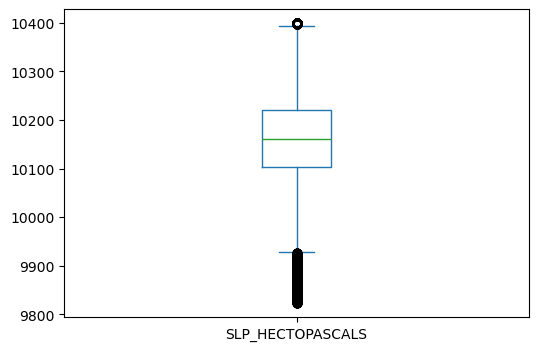

In [64]:
ww_df['SLP_HECTOPASCALS'].plot.box(figsize=(6,4))

In [81]:
ww_df = ww_df[ww_df['SLP_HECTOPASCALS']>9900]

<Axes: >

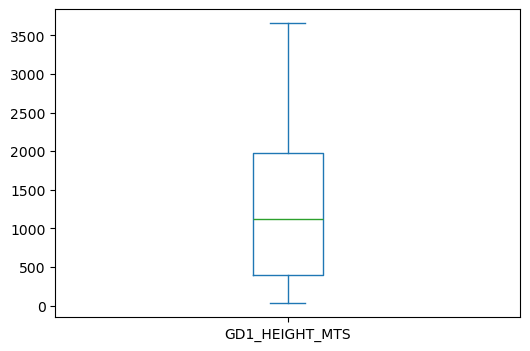

In [82]:
ww_df.GD1_HEIGHT_MTS.plot.box(figsize=(6,4))

In [66]:
ww_df[ww_df.MA1_ALTIMETER_HECTOPASCAL == 99999].shape

(20, 25)

In [67]:
ww_df = ww_df[ww_df.MA1_ALTIMETER_HECTOPASCAL != 99999]

<Axes: >

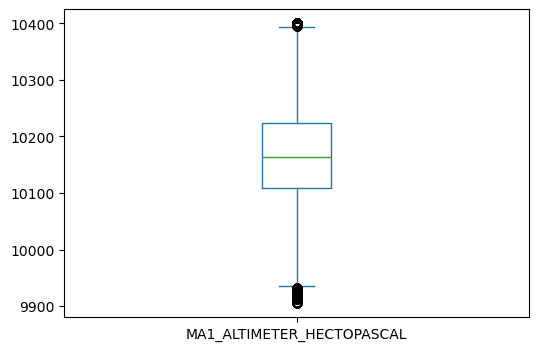

In [83]:
ww_df.MA1_ALTIMETER_HECTOPASCAL.plot.box(figsize=(6,4))

In [86]:
ww_df.rsl_change.describe()

count    450531.000000
mean         -0.129851
std           5.898497
min         -38.000000
25%          -1.000000
50%           0.000000
75%           2.000000
max          38.000000
Name: rsl_change, dtype: float64

In [96]:
ww_df[(ww_df.rsl_change<-5) | (ww_df.rsl_change>5)].shape

(83252, 26)

In [98]:
ww_df = ww_df[(ww_df.rsl_change>-5) & (ww_df.rsl_change<5)]

<Axes: >

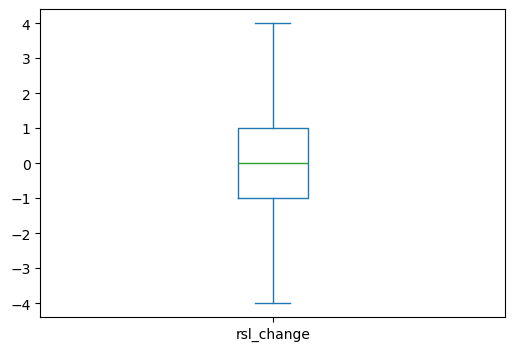

In [99]:
ww_df['rsl_change'].plot.box(figsize=(6,4))

In [100]:
ww_df['rsl_change_mw'] = ww_df.rsl_change.apply(lambda x: 10** (x/10))

C:\Users\ukhan\AppData\Local\Temp\ipykernel_17712\19271581.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ww_df['rsl_change_mw'] = ww_df.rsl_change.apply(lambda x: 10** (x/10))


In [101]:
ww_df['rsl_change_mw'].describe()

count    347843.000000
mean          1.164713
std           0.488949
min           0.398107
25%           0.794328
50%           1.000000
75%           1.258925
max           2.511886
Name: rsl_change_mw, dtype: float64

In [107]:
ww_df[ww_df['rsl_change_mw']>1.6].shape

(40316, 26)

In [108]:
ww_df = ww_df[ww_df['rsl_change_mw']<1.6]

<Axes: >

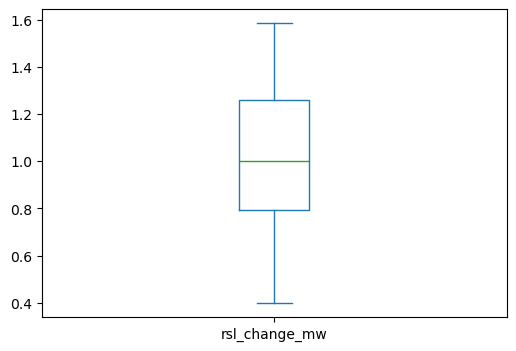

In [109]:
ww_df['rsl_change_mw'].plot.box(figsize=(6,4))

In [111]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length', 'rsl',
       'LATITUDE', 'LONGITUDE', 'ELEVATION', 'WND_SPEED_MPS',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'CIG_AGL', 'VIS_DISTANCE_MTS',
       'SLP_HECTOPASCALS', 'GD1_HEIGHT_MTS', 'GD1__1', 'GD1__2', 'GD1__3',
       'GD1__4', 'GD1__5', 'MA1_ALTIMETER_HECTOPASCAL', 'rsl_change', 'TMP_F',
       'DEW_TMP_F', 'rsl_change_mw'],
      dtype='object')

In [112]:
ww_df.shape

(307527, 26)

In [113]:
ww_df.describe()

,sublink_id,rsl_value,frequency,length,rsl,LATITUDE,LONGITUDE,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,...,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL,rsl_change,TMP_F,DEW_TMP_F,rsl_change_mw
count,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,...,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000,307527.000000
mean,53.553184,-59.464795,26752.740003,1748.671921,-59.577344,40.711098,-74.003972,7.286489,28.169988,0.572662,...,0.104914,0.067978,0.129306,0.267193,0.000351,10167.242297,-0.112549,50.730233,38.036235,1.031481
std,30.010308,6.858544,26852.703911,1295.359424,6.890892,0.025903,0.013250,13.513326,17.047325,0.494693,...,0.306444,0.251708,0.335539,0.442495,0.018737,86.205720,1.517675,13.811813,14.543729,0.330459
min,1.000000,-85.000000,5270.000000,24.500000,-83.000000,40.701214,-74.009028,2.130000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9905.000000,-4.000000,19.040000,-0.940000,0.398107
25%,26.000000,-64.000000,5560.000000,631.400000,-64.000000,40.701214,-74.009028,2.130000,15.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10108.000000,-1.000000,41.000000,26.960000,0.794328
50%,54.000000,-59.000000,5810.000000,1503.400000,-59.000000,40.701214,-74.009028,2.130000,26.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10166.000000,0.000000,48.020000,37.040000,1.000000
75%,80.000000,-55.000000,60480.000000,2791.900000,-56.000000,40.701214,-74.009028,2.130000,36.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,10223.000000,1.000000,60.080000,48.920000,1.258925
max,103.000000,-35.000000,69120.000000,6936.500000,-34.000000,40.778980,-73.969250,42.700000,77.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,10400.000000,2.000000,93.920000,75.920000,1.584893


## Correlation Matrix

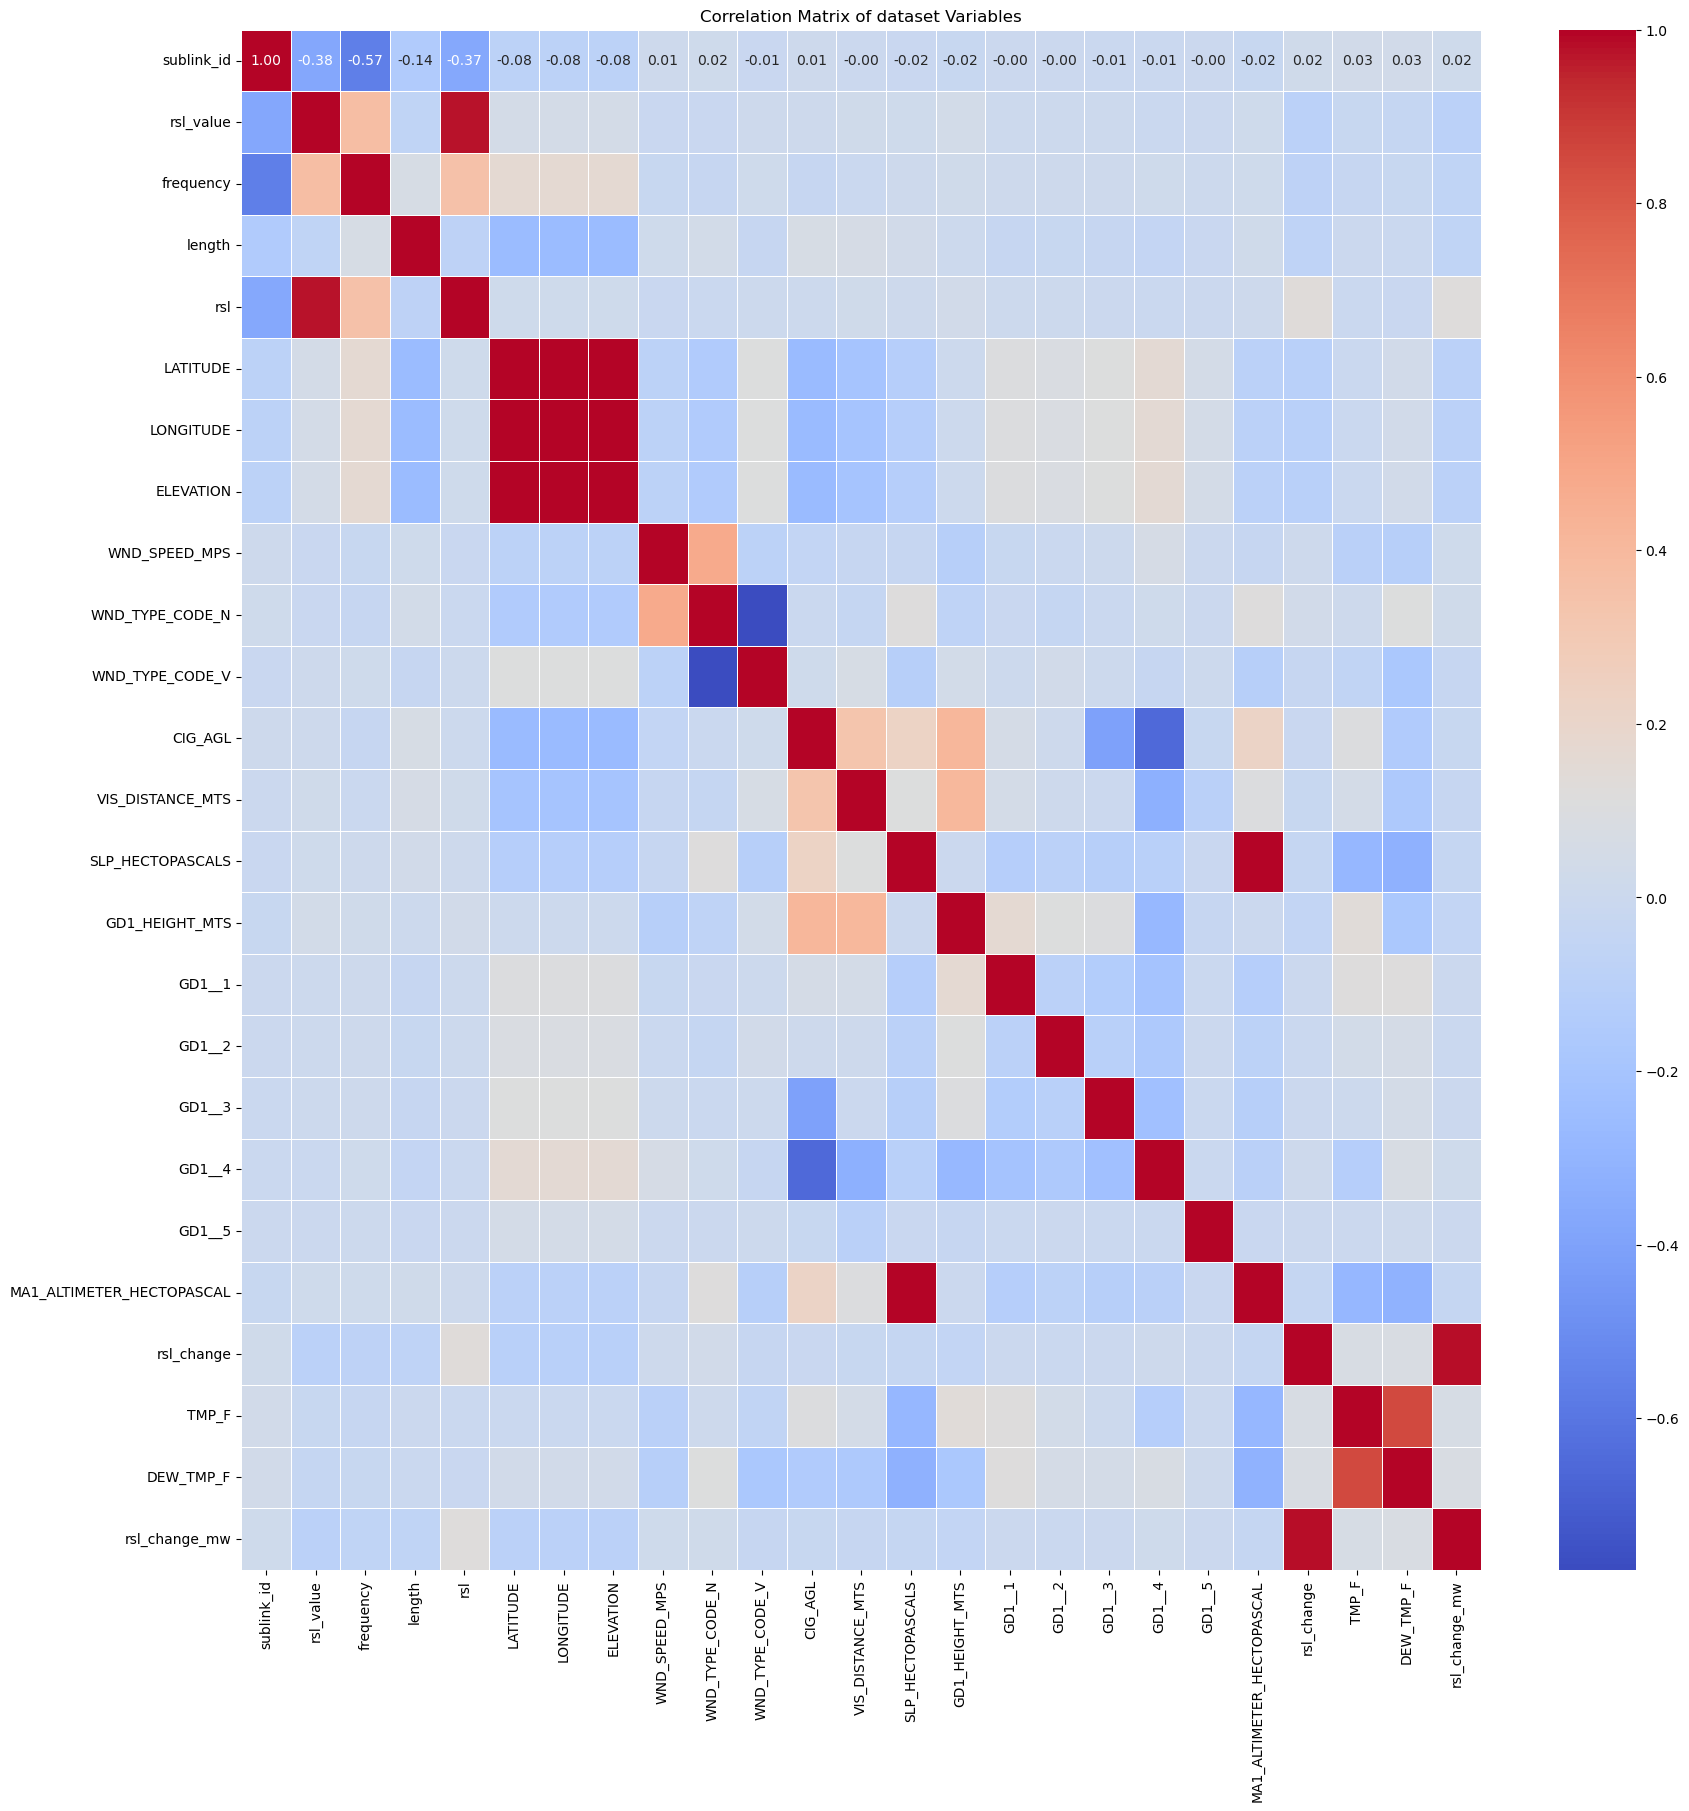

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = ww_df.corr(numeric_only=True)

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of dataset Variables')
plt.show()

In [122]:
correlation_matrix

,sublink_id,rsl_value,frequency,length,rsl,LATITUDE,LONGITUDE,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,...,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,MA1_ALTIMETER_HECTOPASCAL,rsl_change,TMP_F,DEW_TMP_F,rsl_change_mw
sublink_id,1.000000,-0.375262,-0.565997,-0.144681,-0.368487,-0.082515,-0.082515,-0.082515,0.012990,0.018178,...,-0.004879,-0.004793,-0.005552,-0.006014,-0.000039,-0.021438,0.022762,0.030220,0.030219,0.018826
rsl_value,-0.375262,1.000000,0.371757,-0.061695,0.975643,0.043958,0.043958,0.043958,-0.016482,-0.014889,...,0.003936,0.004168,0.002264,-0.009837,-0.001690,0.020105,-0.089277,-0.025421,-0.035603,-0.093083
frequency,-0.565997,0.371757,1.000000,0.070070,0.352553,0.165997,0.165997,0.165997,-0.021368,-0.027239,...,0.014962,0.012604,0.014613,0.017978,0.005164,0.016529,-0.079269,-0.027397,-0.024636,-0.065824
length,-0.144681,-0.061695,0.070070,1.000000,-0.076448,-0.258840,-0.258840,-0.258840,0.019277,0.038868,...,-0.026363,-0.023573,-0.027142,-0.041824,-0.012255,0.028011,-0.068300,0.001221,-0.009385,-0.063436
rsl,-0.368487,0.975643,0.352553,-0.076448,1.000000,0.020517,0.020517,0.020517,-0.013402,-0.007934,...,0.003319,0.002397,0.001241,-0.006999,-0.002107,0.012006,0.131386,-0.009155,-0.017054,0.123146
LATITUDE,-0.082515,0.043958,0.165997,-0.258840,0.020517,1.000000,1.000000,1.000000,-0.083397,-0.148356,...,0.100581,0.089747,0.111196,0.161083,0.049120,-0.089191,-0.105499,-0.006779,0.031906,-0.088871
LONGITUDE,-0.082515,0.043958,0.165997,-0.258840,0.020517,1.000000,1.000000,1.000000,-0.083397,-0.148356,...,0.100581,0.089747,0.111196,0.161083,0.049120,-0.089191,-0.105499,-0.006779,0.031906,-0.088871
ELEVATION,-0.082515,0.043958,0.165997,-0.258840,0.020517,1.000000,1.000000,1.000000,-0.083397,-0.148356,...,0.100581,0.089747,0.111196,0.161083,0.049120,-0.089191,-0.105499,-0.006779,0.031906,-0.088871
WND_SPEED_MPS,0.012990,-0.016482,-0.021368,0.019277,-0.013402,-0.083397,-0.083397,-0.083397,1.000000,0.476090,...,-0.020458,-0.007382,0.003502,0.058264,-0.002783,-0.031602,0.013637,-0.098945,-0.109594,0.015562
WND_TYPE_CODE_N,0.018178,-0.014889,-0.027239,0.038868,-0.007934,-0.148356,-0.148356,-0.148356,0.476090,1.000000,...,-0.017640,-0.039472,-0.009205,0.021688,-0.003455,0.113287,0.031262,0.013920,0.109341,0.028604


In [123]:
#Drop columns with high correlation
ww_df = ww_df.drop(columns=['rsl', 'LATITUDE', 'LONGITUDE', 'rsl_change', 'DEW_TMP_F', 'MA1_ALTIMETER_HECTOPASCAL', 'CIG_AGL', 'GD1_HEIGHT_MTS'])

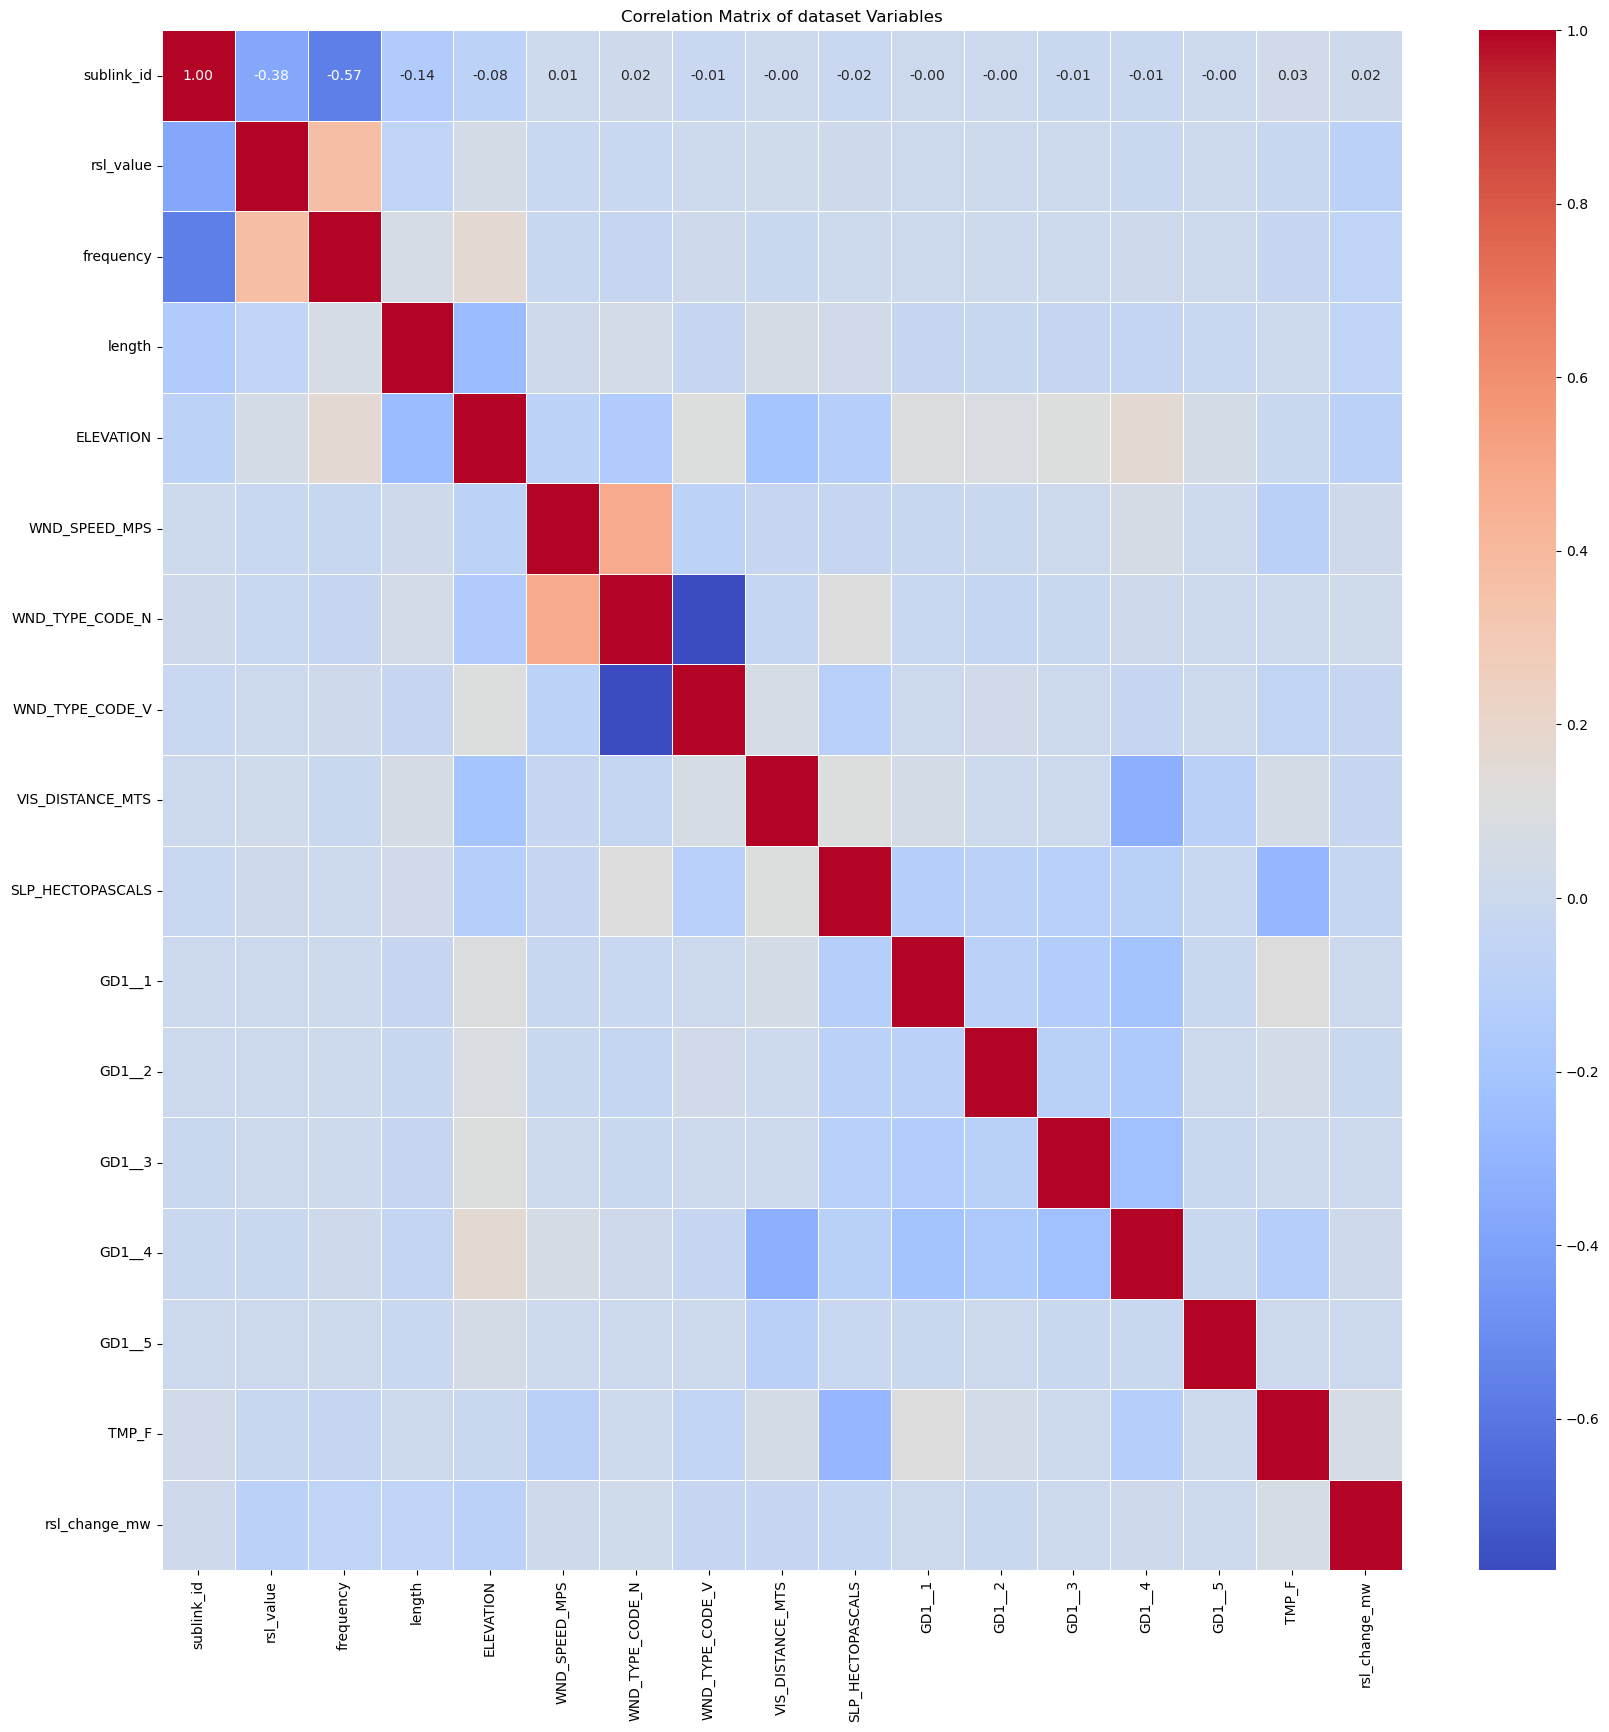

In [124]:
correlation_matrix = ww_df.corr(numeric_only=True)

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of dataset Variables')
plt.show()

In [44]:
max = 34.4
min = -8.3
num_bins = 5
bin_width_lambda = lambda min, max, num_bins: [(max-min)/num_bins*(i+1) for i in range(num_bins)]

In [45]:
bin_width_lambda(min, max, num_bins)

[8.540000000000001,
 17.080000000000002,
 25.620000000000005,
 34.160000000000004,
 42.7]

## Plots

In [126]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V',
       'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS', 'GD1__1', 'GD1__2', 'GD1__3',
       'GD1__4', 'GD1__5', 'TMP_F', 'rsl_change_mw'],
      dtype='object')

In [127]:
ww_df['frequency'].value_counts().reset_index(name='count')

,index,count
0,68040,40758
1,5560,27050
2,5490,25923
3,5710,20605
4,24100,20536
5,24200,18769
6,64800,14093
7,5810,13235
8,58320,11686
9,5760,10150


In [48]:
min = ww_df['frequency'].min()
max = ww_df['frequency'].max()
num_bins = 5
group = (max-min)/num_bins

[min + group*(i) for i in range(num_bins+1)]

[5270.0, 18040.0, 30810.0, 43580.0, 56350.0, 69120.0]

In [128]:
def create_bins(min, max, num_bins=5):
    group = (max-min)/num_bins
    return [min + group*(i) for i in range(num_bins+1)]

In [50]:
create_bins(ww_df.frequency.min(), ww_df.frequency.max())

[5270.0, 18040.0, 30810.0, 43580.0, 56350.0, 69120.0]

In [129]:
ww_df.head()

,Datetime,sublink_id,rsl_value,frequency,length,ELEVATION,WND_SPEED_MPS,WND_TYPE_CODE_N,WND_TYPE_CODE_V,VIS_DISTANCE_MTS,SLP_HECTOPASCALS,GD1__1,GD1__2,GD1__3,GD1__4,GD1__5,TMP_F,rsl_change_mw
1,2023-10-29 00:51:00,2,-59.0,60480,222.1,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.501187
2,2023-10-29 00:51:00,3,-61.0,62640,623.0,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.258925
3,2023-10-29 00:51:00,4,-56.0,58320,451.8,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.794328
4,2023-10-29 00:51:00,5,-58.0,60480,222.1,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,1.258925
5,2023-10-29 00:51:00,6,-48.0,58320,232.6,42.7,36,1,0,16093,10176,0,0,1,0,0,71.96,0.501187


In [130]:
#bins = [0,0.35,0.7,1]
df = ww_df.groupby(pd.cut(ww_df['frequency'], bins=bins)).frequency.count()
df.plot(kind='bar')


NameError: name 'bins' is not defined

<Axes: xlabel='frequency'>

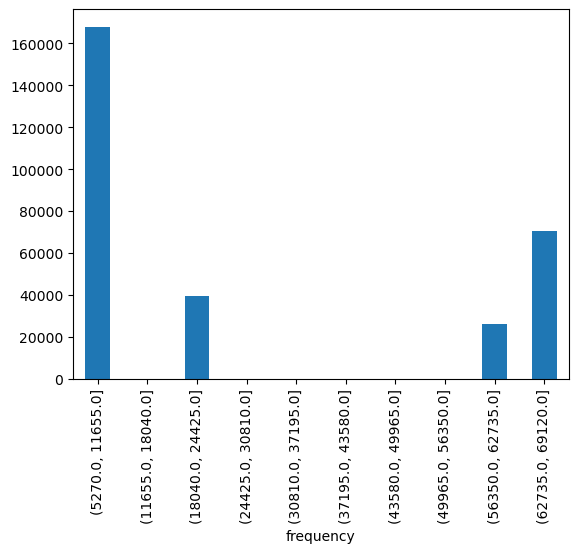

In [131]:
#bins = [0,0.35,0.7,1]
df = ww_df.groupby(pd.cut(ww_df['frequency'], bins=create_bins(ww_df.frequency.min(), ww_df.frequency.max(), 10))).frequency.count()
df.plot(kind='bar')


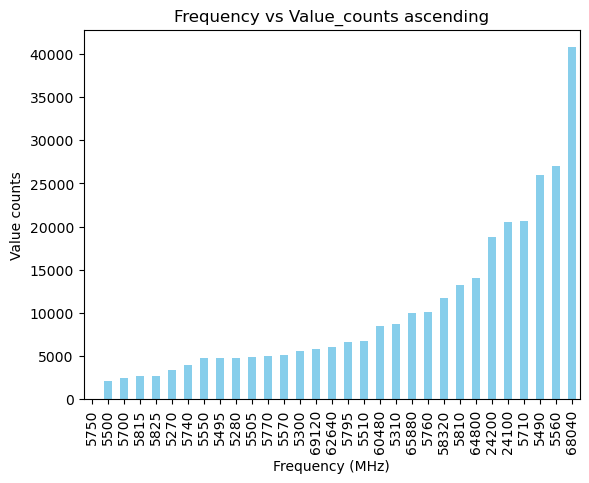

In [132]:
ww_df.frequency.value_counts(ascending=True).plot(kind='bar', color='skyblue')
plt.xlabel("Frequency (MHz)")
plt.ylabel("Value counts")
plt.title("Frequency vs Value_counts ascending")
plt.show()

In [54]:
#sns.displot(data=ww_df['frequency'].value_counts().reset_index(name='count'),
#            x='count', col='index', kind='hist')

In [134]:
ww_df['sublink_id'].value_counts()

25    5457
55    5416
17    5360
44    5304
35    5244
      ... 
51     257
19      79
1       79
27      24
60       1
Name: sublink_id, Length: 99, dtype: int64

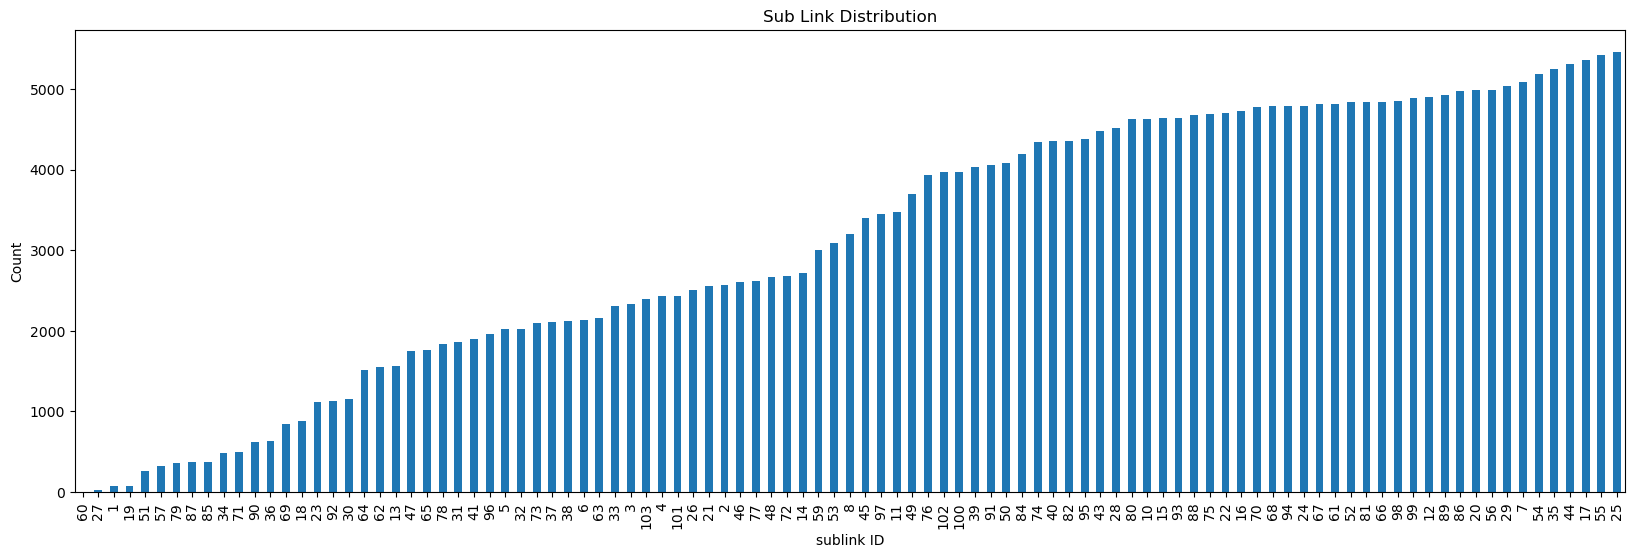

In [141]:
plt.figure(figsize=(20,6))
ww_df['sublink_id'].value_counts(ascending=True).plot(kind='bar')
plt.title("Sub Link Distribution")
plt.xlabel("sublink ID")
plt.ylabel("Count")
plt.show()

In [65]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'LATITUDE', 'LONGITUDE', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C',
       'DEW_TMP_C', 'SLP_HECTOPASCALS'],
      dtype='object')

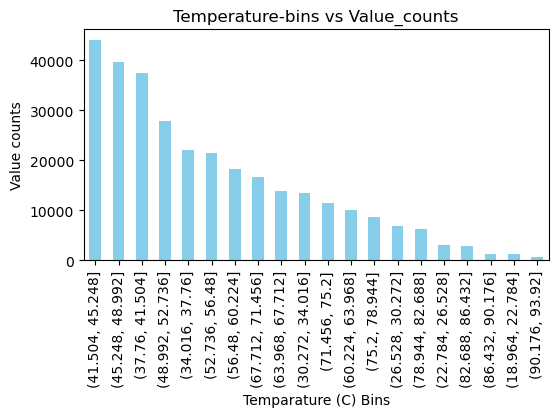

In [146]:
plt.figure(figsize=(6,3))
ww_df.TMP_F.value_counts(bins=20).plot(kind='bar', color='skyblue')
plt.xlabel("Temparature (C) Bins")
plt.ylabel("Value counts")
plt.title("Temperature-bins vs Value_counts")
plt.show()

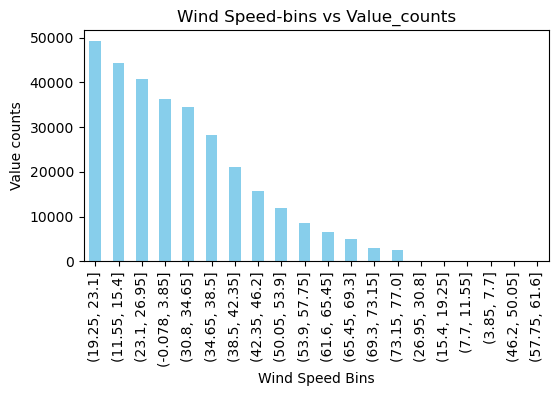

In [145]:
plt.figure(figsize=(6,3))
ww_df.WND_SPEED_MPS.value_counts(bins=20).plot(kind='bar', color='skyblue')
plt.xlabel("Wind Speed Bins")
plt.ylabel("Value counts")
plt.title("Wind Speed-bins vs Value_counts")
plt.show()

In [147]:
ww_df.VIS_DISTANCE_MTS.describe()

count    307527.000000
mean      15180.358534
std        2699.646463
min         402.000000
25%       16093.000000
50%       16093.000000
75%       16093.000000
max       16093.000000
Name: VIS_DISTANCE_MTS, dtype: float64

In [88]:
(ww_df.VIS_DISTANCE_MTS<16093).sum()/ww_df.shape[0]

0.1426911275563915

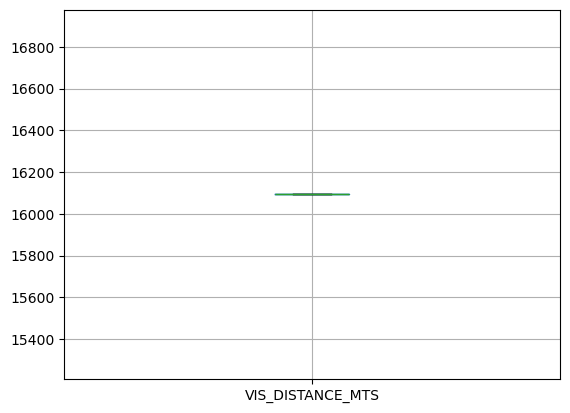

In [148]:
ww_df[ww_df.VIS_DISTANCE_MTS==16093].boxplot(column='VIS_DISTANCE_MTS')
plt.show()

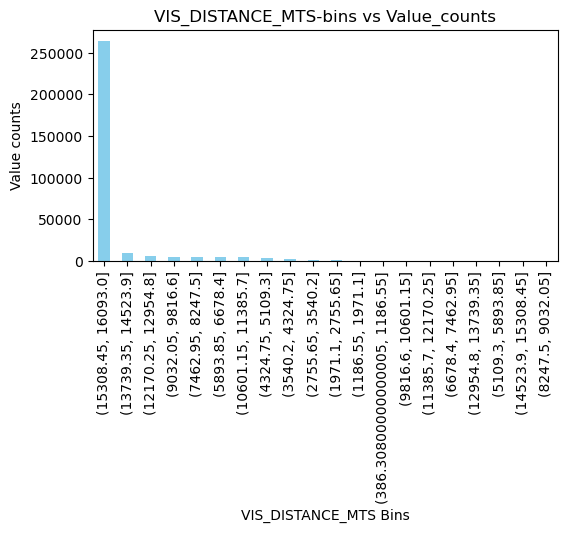

In [149]:
plt.figure(figsize=(6,3))
ww_df.VIS_DISTANCE_MTS.value_counts(bins=20).plot(kind='bar', color='skyblue')
plt.xlabel("VIS_DISTANCE_MTS Bins")
plt.ylabel("Value counts")
plt.title("VIS_DISTANCE_MTS-bins vs Value_counts")
plt.show()

In [90]:
## Avoiding removal to control this feature through RFE

# Scatter plots for multiple variables

In [153]:
def scatter_plot_against_time_for_freq(y_col_name=None, x_col_name='Datetime'):
    # Filter the dataframe for frequency ==
    '''
    freq_list = [62640, 60480, 58320, 68040, 64800,  5310,  5505,  5825, 65880,
                  24100,  5760,  5795,  5560, 24200,  5300,  5270, 69120,  5770,
                  5750,  5495,  5710,  5280,  5550,  5570,  5490,  5815,  5500,
                  5810,  5510,  5740,  5700]
    '''
    freq_list = [62640, 5505, 24100, 69120]
    for frequency in freq_list:
        filtered_df = ww_df[ww_df['frequency'] == frequency].copy()
    
        # Convert 'rsl_value' to numeric, coercing errors
        filtered_df[y_col_name] = pd.to_numeric(filtered_df[y_col_name], errors='coerce')
    
        # Convert 'Datetime' to datetime objects
        filtered_df[x_col_name] = pd.to_datetime(filtered_df[x_col_name])
    
        # Create the scatter plot
        plt.figure(figsize=(10, 2))
        sns.scatterplot(data=filtered_df, x=x_col_name, y=y_col_name, alpha=0.5)
        plt.xlabel(x_col_name)
        plt.ylabel(y_col_name)
        plt.title(y_col_name + 'vs' + x_col_name +' for Frequency '+str(frequency))
        plt.grid(True)
        plt.show()

In [159]:
def scatter_plot_x_y(y_col_name=None, x_col_name='Datetime'):
        filtered_df = ww_df[[x_col_name, y_col_name]].copy()
    
        # Convert 'rsl_value' to numeric, coercing errors
        filtered_df[y_col_name] = pd.to_numeric(filtered_df[y_col_name], errors='coerce')
    
        # Convert 'Datetime' to datetime objects
        filtered_df[x_col_name] = pd.to_datetime(filtered_df[x_col_name])
    
        # Create the scatter plot
        plt.figure(figsize=(10, 2))
        sns.scatterplot(data=filtered_df, x=x_col_name, y=y_col_name, alpha=0.5)
        plt.xlabel(x_col_name)
        plt.ylabel(y_col_name)
        plt.title(y_col_name + 'vs' + x_col_name)
        plt.grid(True)
        plt.show()

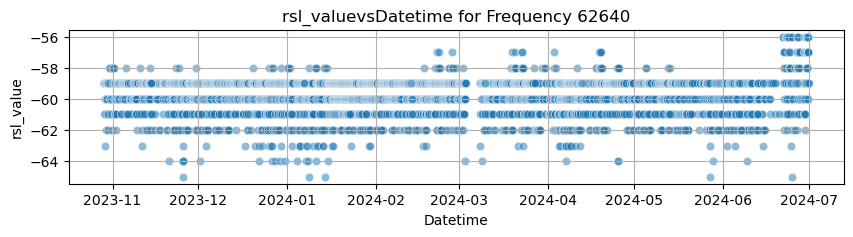

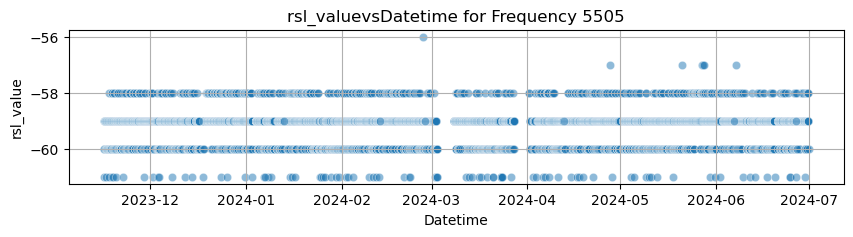

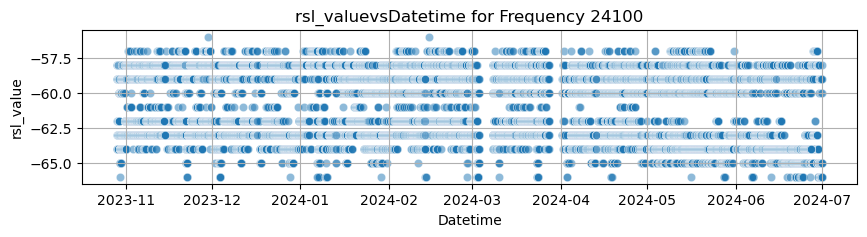

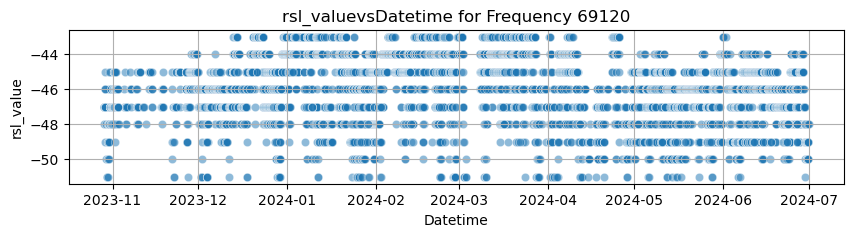

In [154]:
scatter_plot_against_time_for_freq(y_col_name='rsl_value')

In [155]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V',
       'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS', 'GD1__1', 'GD1__2', 'GD1__3',
       'GD1__4', 'GD1__5', 'TMP_F', 'rsl_change_mw'],
      dtype='object')

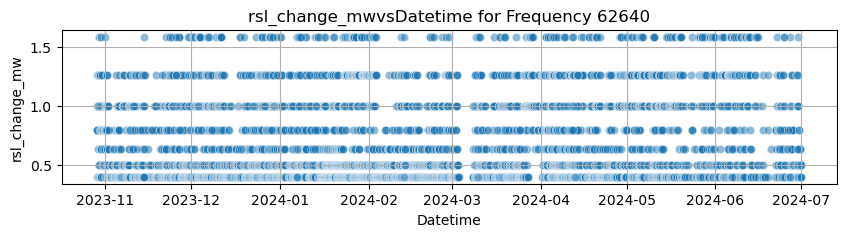

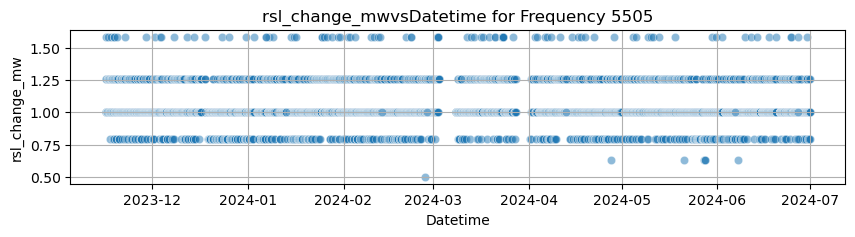

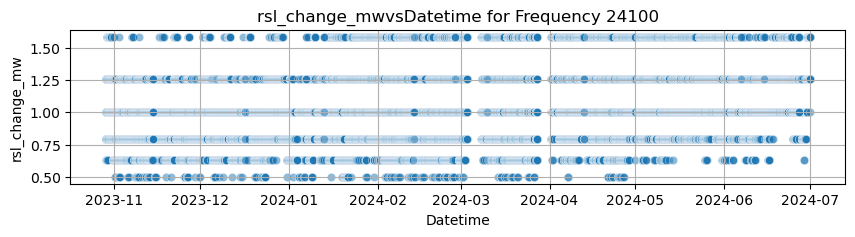

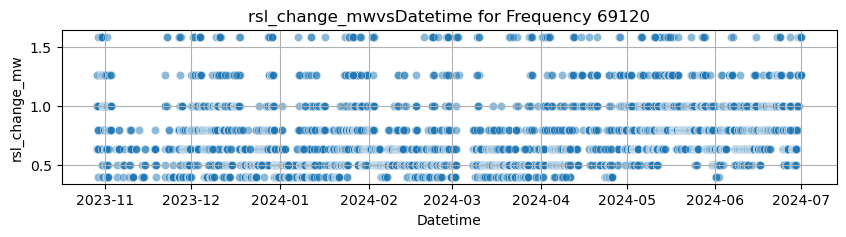

In [156]:
scatter_plot_against_time_for_freq(y_col_name='rsl_change_mw')

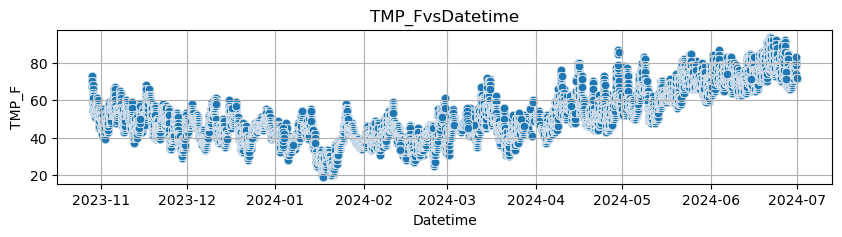

In [160]:
scatter_plot_x_y(y_col_name='TMP_F')

In [161]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V',
       'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS', 'GD1__1', 'GD1__2', 'GD1__3',
       'GD1__4', 'GD1__5', 'TMP_F', 'rsl_change_mw'],
      dtype='object')

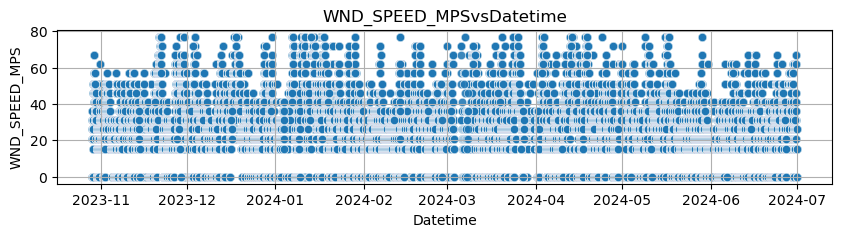

In [164]:
scatter_plot_x_y(y_col_name='WND_SPEED_MPS')

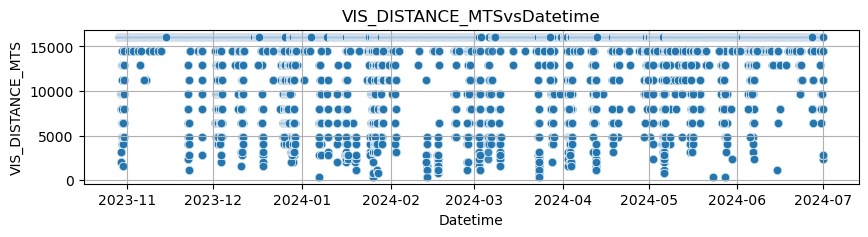

In [165]:
scatter_plot_x_y(y_col_name='VIS_DISTANCE_MTS')

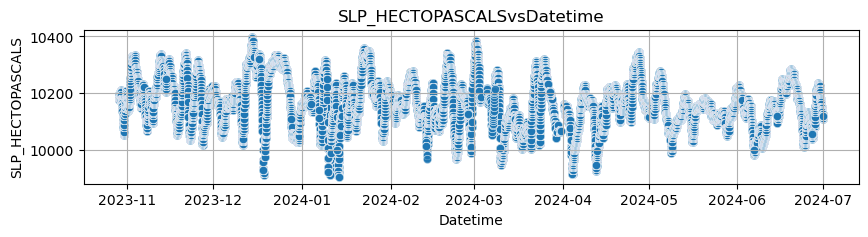

In [166]:
scatter_plot_x_y(y_col_name='SLP_HECTOPASCALS')

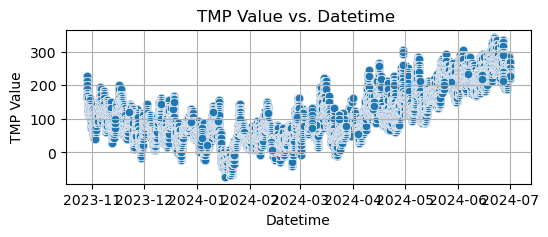

In [22]:
# Create the scatter plot
plt.figure(figsize=(6, 2))
sns.scatterplot(data=ww_df, x='Datetime', y='TMP_C', alpha=0.5)
plt.xlabel('Datetime')
plt.ylabel('TMP Value')
plt.title('TMP Value vs. Datetime ')
plt.grid(True)
plt.show()

In [167]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'ELEVATION', 'WND_SPEED_MPS', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V',
       'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS', 'GD1__1', 'GD1__2', 'GD1__3',
       'GD1__4', 'GD1__5', 'TMP_F', 'rsl_change_mw'],
      dtype='object')

In [168]:
ww_df.shape

(307527, 18)

In [169]:
ww_df.to_csv("C:/Users/ukhan/Documents/DataSet/OpenMesh/wireless_weather_signal_ph2_modelling_data.csv", index=False)